### Cell 1: 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pm4py

# 3D 그래프 출력을 위한 설정
%matplotlib inline

### Cell 2: 1. 가상 PLC 데이터 생성

In [2]:
# 일관된 결과를 위해 시드 고정
np.random.seed(42)

# 길이 10의 바이너리 배열 패턴 4개 정의
phase_0 = np.array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
phase_1 = np.array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0])
phase_2 = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])
phase_3 = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1])
patterns = [phase_0, phase_1, phase_2, phase_3]

# 각 Phase가 10 스텝씩 유지되며 순환하는 1,000 타임스텝 데이터 생성
data_list = []
for i in range(1000):
    # 10 스텝마다 패턴 변경 (0 -> 1 -> 2 -> 3 -> 0 ...)
    current_phase = (i // 10) % 4
    data_list.append(patterns[current_phase])

raw_data = np.array(data_list)

# np.random.rand와 np.logical_xor를 사용하여 약 2%의 무작위 노이즈 추가
noise_mask = np.random.rand(*raw_data.shape) < 0.02
noisy_data = np.logical_xor(raw_data, noise_mask).astype(int)

print(f"원본 데이터 형태: {noisy_data.shape}")

원본 데이터 형태: (1000, 10)


### Cell 3: 2. 슬라이딩 윈도우 전처리

In [3]:
# 시계열 맥락 반영을 위한 슬라이딩 윈도우 (window_size=5)
window_size = 5
windowed_data = []

# 전체 길이에서 윈도우 사이즈만큼 빼준 길이만큼 반복
for i in range(len(noisy_data) - window_size + 1):
    # 5개의 스텝을 하나의 1차원 벡터로 평탄화 (flatten)
    window = noisy_data[i : i + window_size].flatten()
    windowed_data.append(window)

processed_data = np.array(windowed_data)

# 10개의 센서 데이터가 5 윈도우로 묶여 50차원이 됨 (1000-5+1 = 996 데이터 수)
print(f"전처리 후 데이터 형태: {processed_data.shape}")

전처리 후 데이터 형태: (996, 50)


### Cell 4: 3. PCA 차원 축소 및 시각화

PC1, PC2, PC3 개별 분산 설명력: [0.34754398 0.21842023 0.17163858]
총 정보 유지율: 0.7376


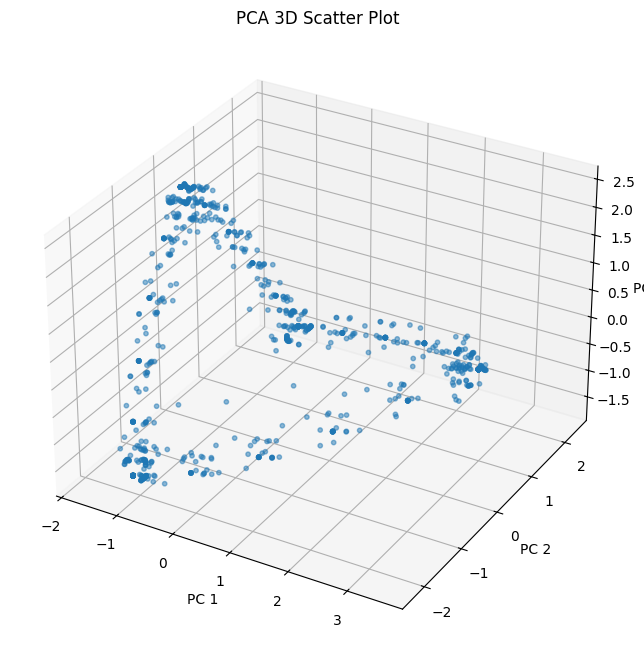

In [4]:
# PCA를 사용해 50차원 데이터를 3차원으로 축소
pca = PCA(n_components=3)
pca_data = pca.fit_transform(processed_data)

# 개별 분산 설명력 및 총 정보 유지율 출력
explained_variance = pca.explained_variance_ratio_
total_variance = np.sum(explained_variance)

print(f"PC1, PC2, PC3 개별 분산 설명력: {explained_variance}")
print(f"총 정보 유지율: {total_variance:.4f}")

# 3차원 산점도 (3D Scatter Plot) 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_data[:, 0], pca_data[:, 1], pca_data[:, 2], s=10, alpha=0.5)

ax.set_title("PCA 3D Scatter Plot")
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
plt.show()

### Cell 5: 4. K-Means 클러스터링

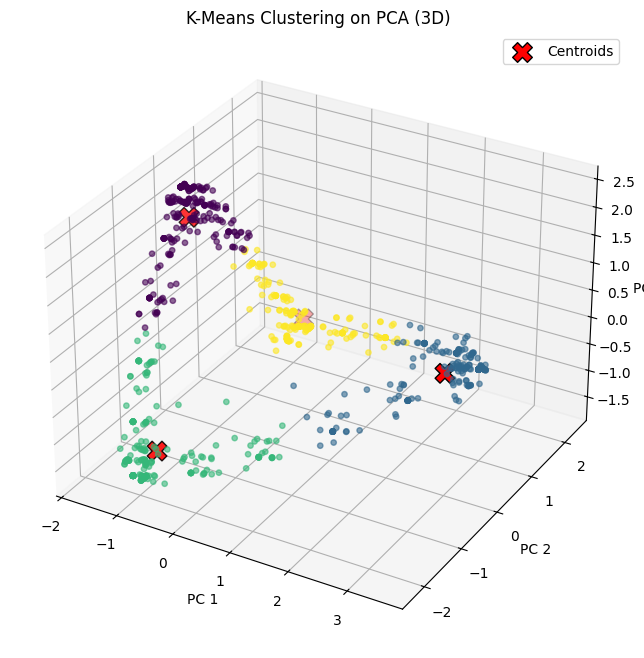

In [5]:
# K-Means 클러스터링 학습 (n_clusters=4)
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(pca_data)

# 클러스터 중심점 추출
centroids = kmeans.cluster_centers_

# 3D 산점도에 클러스터 라벨로 색상 입히고, Centroid 표시
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 데이터 포인트 스캐터 플롯 (클러스터 라벨에 따라 색상 매핑)
scatter = ax.scatter(pca_data[:, 0], pca_data[:, 1], pca_data[:, 2], 
                     c=cluster_labels, cmap='viridis', s=15, alpha=0.6)

# Centroid는 빨간색 'X' 마커로 표시
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], 
           c='red', marker='X', s=200, label='Centroids', edgecolor='black')

ax.set_title("K-Means Clustering on PCA (3D)")
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.legend()
plt.show()

### Cell 6: 5. 정량적 성능 평가 및 6. 시각적 평가 (시계열 변화)

Silhouette Score: 0.7044


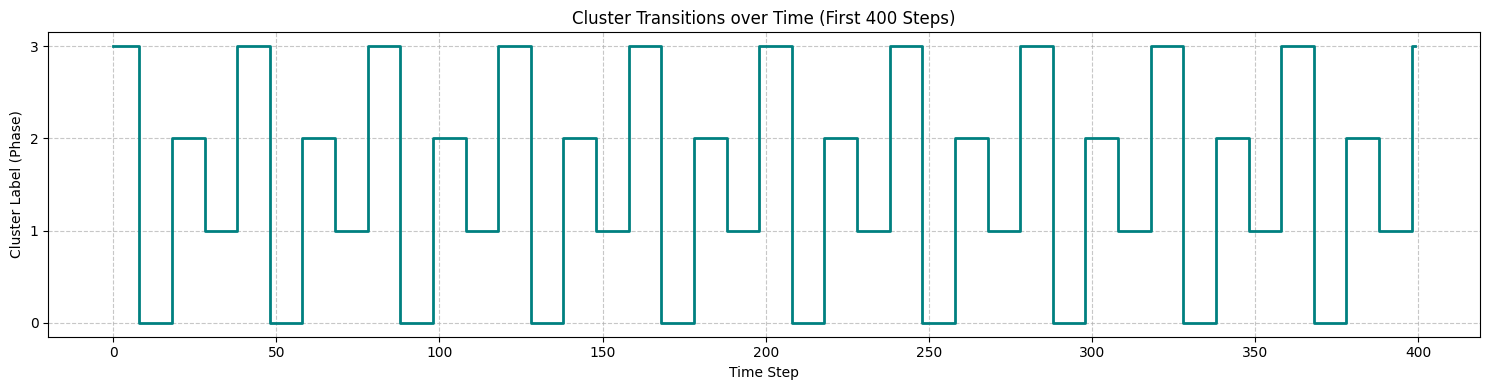

In [6]:
# 5. 정량적 성능 평가: Silhouette Score 계산 (소수점 4자리)
sil_score = silhouette_score(pca_data, cluster_labels)
print(f"Silhouette Score: {sil_score:.4f}")

# 6. 시각적 평가: 처음 400스텝을 계단형 그래프로 표현
plt.figure(figsize=(15, 4))
plt.plot(cluster_labels[:400], drawstyle='steps-post', color='teal', linewidth=2)
plt.title("Cluster Transitions over Time (First 400 Steps)")
plt.xlabel("Time Step")
plt.ylabel("Cluster Label (Phase)")
plt.yticks([0, 1, 2, 3])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Cell 7: 7. 이벤트 로그 데이터프레임 생성

In [7]:
# 타임스탬프 생성 (2026-05-05 10:00:00 부터 1초 단위로 증가)
# pandas 2.2.0 이상부터 "S" 대신 "s"를 사용합니다.
timestamps = pd.date_range(start="2026-05-05 10:00:00", periods=len(cluster_labels), freq="1s")

# 클러스터 라벨을 "Phase_N" 형태로 변환
activities = [f"Phase_{label}" for label in cluster_labels]

# 데이터프레임 생성
log_df = pd.DataFrame({
    "case_id": "Mitsubishi_Line_1",
    "activity": activities,
    "timestamp": timestamps
})

print(log_df.head(15))

              case_id activity           timestamp
0   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:00
1   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:01
2   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:02
3   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:03
4   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:04
5   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:05
6   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:06
7   Mitsubishi_Line_1  Phase_3 2026-05-05 10:00:07
8   Mitsubishi_Line_1  Phase_0 2026-05-05 10:00:08
9   Mitsubishi_Line_1  Phase_0 2026-05-05 10:00:09
10  Mitsubishi_Line_1  Phase_0 2026-05-05 10:00:10
11  Mitsubishi_Line_1  Phase_0 2026-05-05 10:00:11
12  Mitsubishi_Line_1  Phase_0 2026-05-05 10:00:12
13  Mitsubishi_Line_1  Phase_0 2026-05-05 10:00:13
14  Mitsubishi_Line_1  Phase_0 2026-05-05 10:00:14


### Cell 8: 8. 프로세스 맵(DFG) 도출 및 시각화

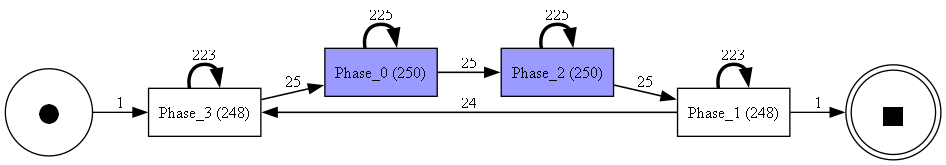

In [8]:
# pm4py 포맷에 맞게 데이터프레임 셋업
formatted_log = pm4py.format_dataframe(
    log_df, 
    case_id='case_id', 
    activity_key='activity', 
    timestamp_key='timestamp'
)

# Directly-Follows Graph (DFG) 도출
dfg, start_activities, end_activities = pm4py.discover_dfg(formatted_log)

# 프로세스 맵 뷰어 실행 (팝업 이미지로 결과 확인)
pm4py.view_dfg(dfg, start_activities, end_activities)